#Importar librerías y Drive

In [6]:
from sklearn.cluster import KMeans
import cv2
import os
import numpy as np
from google.colab import drive
from google.colab.patches import cv2_imshow
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Acceso a las imágenes:

La imagen usada en este repositorio se puede descargar de: https://github.com/rubenchov/VisionComputador

Se debe pegar en una carpeta de Drive de la misma cuenta en la que se usa Google Colab, actualizar a continuación la ruta base y nombre del archivo de imagen

In [8]:
path = '/content/drive/MyDrive/2026/Docencia/Visión con IA/1. Visión Artificial/9 Intro Python OpenCV' #Actualizar ruta dependiendo de dónde descargue las imágenes
img_name = 'IslaMujeres.jpg' #Actualizar también el nombre de la imagen dependiendo de cuál se descargó.
img_path =  os.path.join(path, img_name)

Read image

Cant datos:  764322


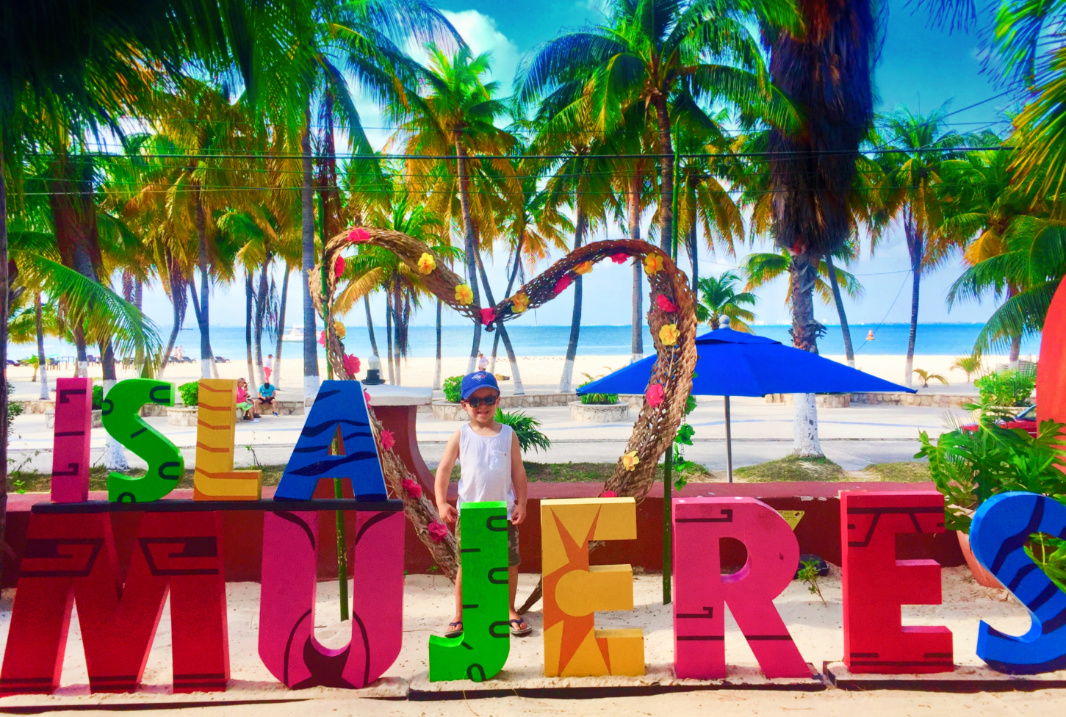

In [14]:
img = cv2.imread(img_path, cv2.IMREAD_COLOR) #Es importante que sea COLOR para leer en formato BGR
h, w, c = img.shape #Se obtienen las filas, columnas y número de canales
print('Cant datos: ', h*w)
cv2_imshow(img)

#Entrenar modelo K-means

En este caso se entrena directamente el modelo para 5 grupos (k=5) antes de hacer cualquier preprocesamiento a la imagen.

In [18]:
X = img.reshape(h*w, 3) #Se aplana la imagen
k = 5 #Se define el número de clases
kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X) #Se define el modelo y de una vez se entrena
print('Centers:', kmeanModel.cluster_centers_) #Se imprimen los centros encontrados
print('Labels: ', kmeanModel.labels_) #Se imprimen las etiquetas asignadas, serán de 0....k
print('Unique labels: ', np.unique(kmeanModel.labels_)) # Se imprimen las etiquetas sin repetir ninguna, se esperan valores de 0...k

Centers: [[ 71.02690003 132.19157061 169.40376996]
 [ 25.79995652  74.38092957  38.61334616]
 [213.13364756 216.08497331 211.504716  ]
 [ 46.75570035  21.92331169 158.15363498]
 [187.01546137 122.25870172  35.56531116]]
Labels:  [1 1 1 ... 2 2 2]
Unique labels:  [0 1 2 3 4]


Recalcular imagen pero en este caso tener en cuenta sólo los 'k' centros encontrados

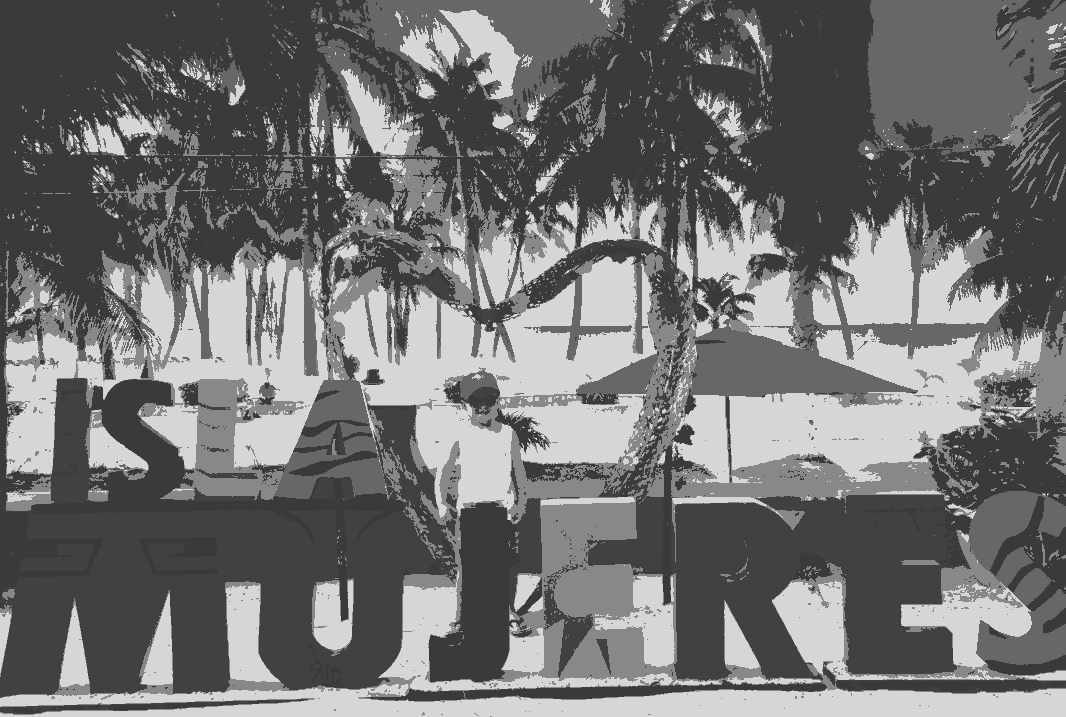

In [21]:
imgk = kmeanModel.cluster_centers_[kmeanModel.labels_].reshape(h, w, 3).astype(np.uint8)
imgk = cv2.cvtColor(imgk, cv2.COLOR_BGR2GRAY)
cv2_imshow(imgk)

Ahora se repite el procedimiento, pero haciendo un difuminado previo para agrupar mejor:

In [24]:
img_blur = cv2.blur(img, (5, 5))
X = img_blur.reshape(h*w, 3) #Se aplana la imagen
k = 5 #Se define el número de clases
kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X) #Se define el modelo y de una vez se entrena
print('Centers:', kmeanModel.cluster_centers_) #Se imprimen los centros encontrados
print('Labels: ', kmeanModel.labels_) #Se imprimen las etiquetas asignadas, serán de 0....k
print('Unique labels: ', np.unique(kmeanModel.labels_)) # Se imprimen las etiquetas sin repetir ninguna, se esperan valores de 0...k

Centers: [[ 47.4475998   22.63622585 157.61393916]
 [ 79.74109631 130.63257502 165.79946853]
 [ 27.07875541  78.25140379  41.80801602]
 [210.45820164 212.88637448 208.58357146]
 [185.04790313 124.10831134  40.12426862]]
Labels:  [2 2 2 ... 3 3 3]
Unique labels:  [0 1 2 3 4]


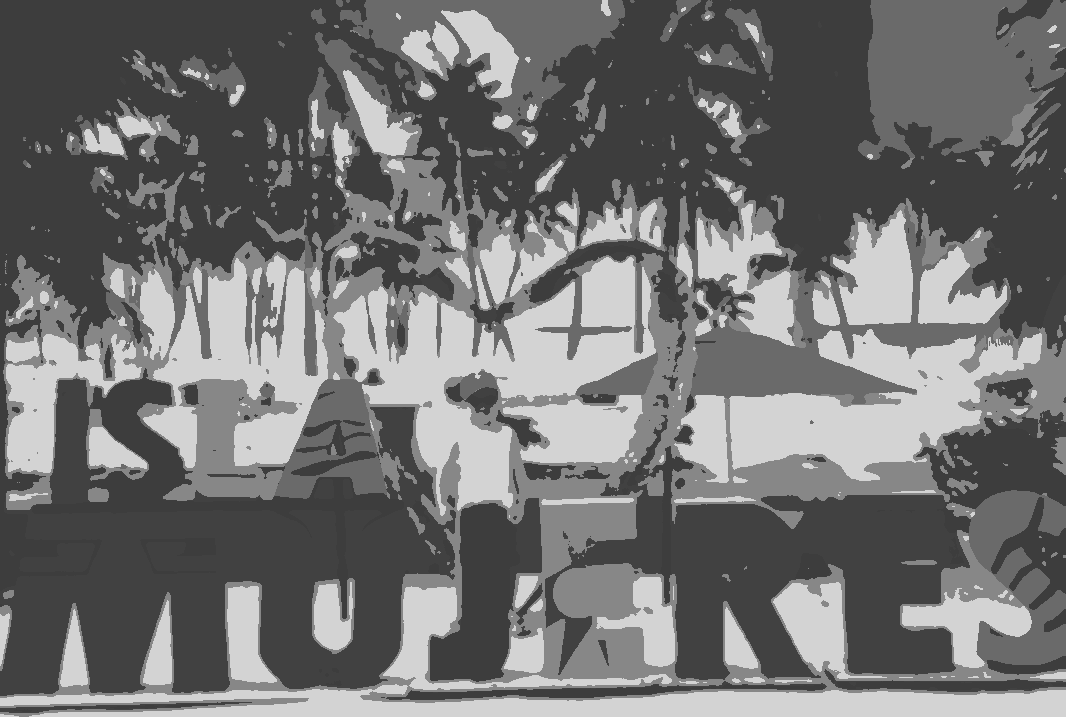

In [25]:
imgk = kmeanModel.cluster_centers_[kmeanModel.labels_].reshape(h, w, 3).astype(np.uint8)
imgk = cv2.cvtColor(imgk, cv2.COLOR_BGR2GRAY)
cv2_imshow(imgk)

En este caso, ya que se hizo una difuminación (blur) antes de agrupar, se evita mucho el ruido al momento de ejecutar el algoritmo K-means, lo cual es una práctica muy recomendada.